In [1]:
import os
import gc
import logging
import pandas as pd
import numpy as np

try:
    %run setup_paths
except:
    %run notebooks/setup_paths
    

logging.basicConfig(
    level=logging.INFO,  # or DEBUG, WARNING, etc.
    format='%(asctime)s - %(levelname)s - %(message)s',
    stream=sys.stdout
)

logging.info(f"current dir: {os.getcwd()}")


2026-09-20 08:46:31,534 - INFO - current dir: c:\Projects\CausalBenchmarkMTGClean


In [2]:
df = pd.read_csv("results/baselines.comparison.csv")

# Summary

In [5]:
summary_df = df.groupby('set_code').agg(
    Total_Pairs=('card_a', 'size'),
    Treatments=('card_a', 'nunique'),
    Outcome_Groups=('group_b', 'nunique')
    
).reset_index()

all_row = {
    'set_code': 'All',
    'Total_Pairs': summary_df['Total_Pairs'].sum(),
    'Treatments': len(df['card_a'].unique()),
    'Outcome_Groups': len(df['group_b'].unique()),
}

summary_df = pd.concat([summary_df, pd.DataFrame([all_row])], ignore_index=True).rename(columns={
    'set_code': 'Set Code',
    'Total_Pairs': 'Total Pairs',
    'Outcome_Groups': 'Outcome Groups'
})

summary_df


,Set Code,Total Pairs,Treatments,Outcome Groups
0,BLB,2184,52,42
1,DFT,2585,47,55
2,DSK,2496,48,52
3,MKM,3250,50,65
4,All,10515,197,91


In [7]:
METHOD_NAMES = {
    
    "dragonnet_cate_att": "DragonNet",

    "dr_att_gbm": "Doubly Robust",
    "cf_att": "Causal Forest",

    "dm_impute_t_att_lin": "T-Imputation (Linear)",
    "dm_impute_t_att_gbm": "T-Imputation (GBM)",
    

     "sipw_logit": "IPW (Logistic)",
    "sipw_gbm": "IPW (GBM)",

    "match_cov_k3": "Covariate Matching",
    "match_ps_logit_k3": "PS Matching (Logistic)",
    "match_ps_gbm_k3": "PS Matching (GBM)",
    

    "satt": "SATT",    
    "null_zero": "Null",
  
}

baseline_cols = list(METHOD_NAMES.keys())
res_cols = ["method","rmse","mae","ccc","accuracy95"]
res_sci_cols = ["method","rmse","rmse_sci","mae","mae_sci","ccc","ccc_sci","accuracy95","accuracy95_sci"]

# Main Results

In [8]:
%run src/evaluation
df, _ = add_null_baselines(df)


In [9]:
%run src/evaluation
res = evaluate_methods(df, baseline_cols, bounds=False)
res[res_sci_cols]

,method,rmse,rmse_sci,mae,mae_sci,ccc,ccc_sci,accuracy95,accuracy95_sci
0,cf_att,0.029778,0.001814,0.015973,0.000961,0.895989,0.013865,0.976015,0.003866
1,dragonnet_cate_att,0.030799,0.001825,0.016662,0.000991,0.890682,0.014672,0.970569,0.004034
2,dr_att_gbm,0.030940,0.001832,0.016401,0.000991,0.892054,0.014749,0.974486,0.004073
3,dm_impute_t_att_gbm,0.032068,0.001860,0.016968,0.001015,0.887035,0.015211,0.970473,0.004692
4,dm_impute_t_att_lin,0.032947,0.001938,0.017179,0.001036,0.882653,0.015931,0.969804,0.004613
5,sipw_gbm,0.039131,0.003178,0.019242,0.001306,0.849297,0.024383,0.952508,0.007967
6,match_ps_gbm_k3,0.039561,0.003382,0.020109,0.001291,0.838285,0.026495,0.939417,0.008347
7,match_cov_k3,0.041118,0.003395,0.020625,0.001338,0.834347,0.025883,0.937028,0.008131
8,sipw_logit,0.041118,0.003191,0.020126,0.001343,0.839978,0.024354,0.945533,0.008115
9,match_ps_logit_k3,0.041558,0.003232,0.020754,0.001349,0.832611,0.025885,0.933779,0.008511


## Difference Significance

In [22]:
nonsig = lambda x: x[~((x["rmse"] != '~') & (x["rmse"] == x["mae"]) & (x["mae"] == x["ccc"]) & (x["ccc"] == x["accuracy95"]))]

In [23]:
%run src/sigmat
sigmat = generate_significance_matrix(df, baseline_cols, one_sided=False, cluster_col="card_a")

In [24]:
nonsig(sigmat)

,method_a,method_b,n_pairs,n_clusters,rmse,mae,ccc,accuracy95
0,dragonnet_cate_att,dr_att_gbm,10515,197,~,<,~,<
2,dragonnet_cate_att,dm_impute_t_att_lin,10515,197,>,>,>,~
3,dragonnet_cate_att,dm_impute_t_att_gbm,10515,197,>,>,>,~
11,dr_att_gbm,cf_att,10515,197,<,<,<,~
30,dm_impute_t_att_lin,dm_impute_t_att_gbm,10515,197,<,<,<,~
46,sipw_logit,match_cov_k3,10515,197,~,>,>,>
47,sipw_logit,match_ps_logit_k3,10515,197,~,>,>,>
48,sipw_logit,match_ps_gbm_k3,10515,197,<,~,~,>
53,sipw_gbm,match_ps_gbm_k3,10515,197,~,>,>,>
56,match_cov_k3,match_ps_logit_k3,10515,197,~,~,~,~


## Plots

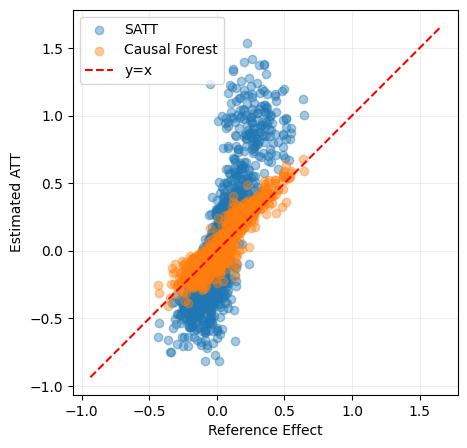

In [28]:

import matplotlib.pyplot as plt
col_x = 'late'


plt.figure(figsize=(5, 5))
def add(col_y, alpha=0.5):
    plt.scatter(df[col_x], df[col_y], alpha=0.4, label=METHOD_NAMES[col_y])
add('satt')
add('cf_att')
# Get current axis limits to draw the line across the whole plot
ax = plt.gca()
min_val = min(ax.get_xlim()[0], ax.get_ylim()[0])
max_val = max(ax.get_xlim()[1], ax.get_ylim()[1])
# Plot the y=x line
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='y=x')

ax.set_aspect('equal')
plt.grid(True, alpha=0.3, linewidth=0.5)
plt.gca().set_axisbelow(True)
plt.xlabel("Reference Effect")
plt.ylabel("Estimated ATT")
plt.legend()
plt.show()

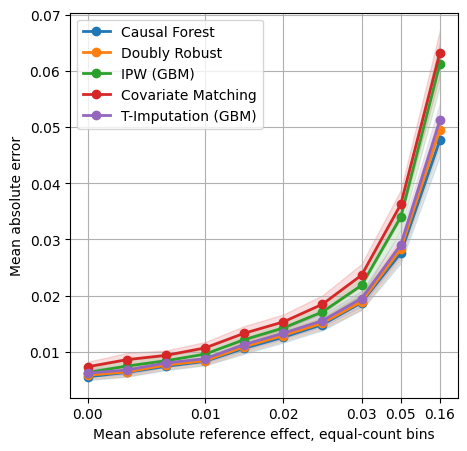

In [30]:
%run src/latex
base = 'match_cov_k3'
ys = ['cf_att','dr_att_gbm','sipw_gbm', 'match_cov_k3', 'dm_impute_t_att_gbm'] #'dragonnet_cate_att']
value_per_quanta(
    #(df[base]-df['late']).abs(),
    df['late'].abs(),
    [(df[x]-df['late']).abs() for x in ys],
    num_bins=10,
    quantile_based=True,
    ci_level=0.95,
    title=None,
    xlabel='Mean absolute reference effect, equal-count bins',
    ylabel='Mean absolute error',
    labels=[METHOD_NAMES[nm] for nm in ys],
    #show_y_equals_x=True,
    show_last_bin=True,
    show=False,
    x_transform=True
)

# Checks 

## Set Code Comparison

In [67]:
%run src/latex
adf = df
ALL_SETS  = list(df.set_code.unique())
res_map = {sss : evaluate_methods(df[(df["set_code"] == sss)], baseline_cols, confidence=False) for sss in ALL_SETS}
print_ranking_correlations(compute_ranking_correlations(res_map))




MAE
     MKM  DSK  DFT  BLB
MKM 1.00 0.99 1.00 0.97
DSK 0.99 1.00 0.99 0.99
DFT 1.00 0.99 1.00 0.97
BLB 0.97 0.99 0.97 1.00

RMSE
     MKM  DSK  DFT  BLB
MKM 1.00 0.94 0.97 0.98
DSK 0.94 1.00 0.98 0.98
DFT 0.97 0.98 1.00 0.98
BLB 0.98 0.98 0.98 1.00

CCC
     MKM  DSK  DFT  BLB
MKM 1.00 0.95 0.94 0.99
DSK 0.95 1.00 0.99 0.96
DFT 0.94 0.99 1.00 0.94
BLB 0.99 0.96 0.94 1.00

ACCURACY95
     MKM  DSK  DFT  BLB
MKM 1.00 0.94 0.96 0.96
DSK 0.94 1.00 0.97 0.92
DFT 0.96 0.97 1.00 0.95
BLB 0.96 0.92 0.95 1.00


## RSC Sensitivity

In [69]:
def eval_rsc(df, r, threshold):
    parts = []
    for set_code in list(df["set_code"].unique()):
        sub = df[df["set_code"]==set_code]
        sub = sub[rank_separation_criterion_mask(sub, r=r, threshold=threshold)]
        parts.append(sub)
    df = pd.concat(parts)
    return df, evaluate_methods(df, baseline_cols, confidence=False)     


In [70]:
from scipy.stats import spearmanr
import pandas as pd


def rsc_sensitivity_table(df, res, values, vary="r", fixed_value=1.96):
    metrics = [m for m, _ in METRICS_CAPTIONS]

    rows = []

    for value in values:
        if vary == "r":
            r = value
            threshold = fixed_value
        elif vary == "threshold":
            r = fixed_value
            threshold = value
        else:
            raise ValueError("vary must be 'r' or 'threshold'")

        rsc_df, rsc_res = eval_rsc(df, r, threshold)

        # Estimator rankings
        all_results = res.set_index("method")
        rsc_results = rsc_res.set_index("method")

        common = all_results.index.intersection(rsc_results.index)

        row = {
            "value": value,
            "remaining": len(rsc_df) / len(df),
        }

        for metric in metrics:
            row[metric] = spearmanr(
                all_results.loc[common, metric],
                rsc_results.loc[common, metric]
            ).statistic

        rows.append(row)

    return pd.DataFrame(rows)

In [72]:
rsc_sen_r = rsc_sensitivity_table(df,  res, [0.1,0.2,0.3,0.4,0.5], vary="r", fixed_value=1.96)
rsc_sen_r

,value,remaining,rmse,mae,ccc,accuracy95
0,0.1,0.225392,0.986014,1.000000,0.979021,0.970229
1,0.2,0.439372,0.986014,1.000000,0.993007,0.965035
2,0.3,0.508131,0.993007,0.993007,0.993007,0.965035
3,0.4,0.522492,0.986014,0.993007,0.993007,0.965035
4,0.5,0.650785,0.993007,0.986014,0.993007,0.965035


In [74]:
rsc_sen_g = rsc_sensitivity_table(df,  res, [1,1.5,1.96,2.5,3], vary="threshold", fixed_value=0.5)
rsc_sen_g

,value,remaining,rmse,mae,ccc,accuracy95
0,1.00,0.913267,0.993007,0.993007,1.000000,0.998250
1,1.50,0.781360,0.986014,0.993007,0.993007,0.977234
2,1.96,0.650785,0.993007,0.986014,0.993007,0.965035
3,2.50,0.518878,0.986014,0.986014,0.979021,0.965035
4,3.00,0.419211,0.986014,0.993007,0.965035,0.965035
